# SIPEDULI — Hybrid Continuous Risk Scoring
## Notebook 04: Unsupervised Labeling + Supervised Regression

---

### Pipeline Dua Tahap

| Tahap | Metode | Output |
|---|---|---|
| **1 — Unsupervised Labeling** | K-Means (k=3) pada 7 urgency-signal features | `risk_score` kontinu [0–100] |
| **2 — Supervised Regression** | Feature Union → PyCaret → Optuna | Model produksi siap deploy |

### Dataset
```
Real scraping berita kriminal  : 2.413 baris  →  KMeans labeling + training
Synthetic user reports         :   600 baris  →  training saja
Total supervised training      : 3.013 baris
```

### Hasil Akhir
| Metrik | Train | Test |
|---|---|---|
| R² | 0.9929 | **0.9579** |
| RMSE | 1.69 | **4.21** |
| MAE | 0.96 | **2.13** |

## 1. Setup & Konfigurasi

In [1]:
# ============================================================
# Import semua library yang dibutuhin di notebook ini.
# Dikelompokin biar gampang cari kalau ada yang kurang.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings
import json
from pathlib import Path

# Scikit-learn: clustering, scaling, evaluasi, vectorizer, split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# LightGBM: model regresi yang kita pakai
from lightgbm import LGBMRegressor

# Optuna: hyperparameter tuning otomatis
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────
# Cari root project secara otomatis dengan naik folder sampai ketemu folder 'data/'
# Trik ini supaya notebook bisa jalan dari mana aja, gak harus dari root
NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'data' / 'dataset_siap_training.csv'
MODEL_DIR = ROOT / 'backend' / 'ml' / 'models'
DOCS_DIR  = ROOT / 'docs'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'ROOT      : {ROOT}')
print(f'DATA_PATH : {DATA_PATH}')
print(f'Ada file? : {DATA_PATH.exists()}')
print(f'MODEL_DIR : {MODEL_DIR}')

ROOT      : C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting
DATA_PATH : C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\data\dataset_siap_training.csv
Ada file? : True
MODEL_DIR : C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\backend\ml\models


## 2. Load & Filter Dataset

Dataset diambil dari hasil scraping berita kriminal. Hanya data real (`is_synthetic == 'No'`) yang dipakai untuk clustering — data SMOTE dieksklusi karena tidak merepresentasikan nuansa semantik teks asli.

Kolom `label_urgensi` dan `label_asal` di-drop sebelum clustering untuk memastikan **zero label bias**.

In [2]:
# ============================================================
# Load dataset dan filter data asli (is_synthetic == 'No').
#
# Kenapa hanya data asli?
# Data SMOTE itu data buatan hasil augmentasi statistik.
# Kalau kita pakai buat clustering, cluster yang terbentuk bisa
# bias karena SMOTE nggak nangkap nuansa semantik teks yang nyata.
# Jadi kita hanya pakai data real dari scraping berita kriminal.
# ============================================================

df_full = pd.read_csv(DATA_PATH)

print(f'Total semua data (termasuk SMOTE): {len(df_full):,} baris')
print(f'  - Data asli (is_synthetic=No)  : {(df_full["is_synthetic"] == "No").sum():,} baris')
print(f'  - Data sintetik (SMOTE)        : {(df_full["is_synthetic"] != "No").sum():,} baris')
print()

# Simpan label lama untuk keperluan VALIDASI di akhir (informatif saja!)
# PENTING: label ini TIDAK BOLEH dipakai sebagai target/fitur training
# kita simpan dulu supaya nanti bisa cross-check apakah risk_score kita masuk akal
df_label_ref = df_full[df_full['is_synthetic'] == 'No'][['id', 'label_urgensi']].copy()
print(f'Label referensi disimpan untuk validasi akhir: {len(df_label_ref)} baris')

# ── Filter: hanya data asli ───────────────────────────────────
df_real = df_full[df_full['is_synthetic'] == 'No'].copy()
df_real = df_real.drop_duplicates(subset=['deskripsi_bersih'])  # hapus duplikat
df_real = df_real[df_real['deskripsi_bersih'].str.len() > 15]   # hapus yang terlalu pendek
df_real = df_real.dropna(subset=['deskripsi_bersih']).reset_index(drop=True)

# ── Drop kolom label lama — INI WAJIB! ───────────────────────
# Kalau label lama masih ada, bisa 'mencemari' proses clustering
# dan kita pengen beneran mulai dari nol tanpa bias label sebelumnya
df_real = df_real.drop(columns=['label_urgensi', 'label_asal'], errors='ignore')

print(f'\nData real bersih yang dipakai: {len(df_real):,} baris')
print(f'Kolom: {df_real.columns.tolist()}')
print('\nLabel lama sudah di-drop. Siap clustering dari nol!')

Total semua data (termasuk SMOTE): 4,371 baris
  - Data asli (is_synthetic=No)  : 2,413 baris
  - Data sintetik (SMOTE)        : 1,958 baris

Label referensi disimpan untuk validasi akhir: 2413 baris

Data real bersih yang dipakai: 2,413 baris
Kolom: ['id', 'judul_berita', 'deskripsi_kejadian', 'lokasi_kejadian', 'waktu_kejadian', 'kategori_kejahatan', 'sumber', 'url', 'scraped_at', 'deskripsi_original', 'deskripsi_bersih', 'keywords_highlight', 'is_synthetic', 'risk_score']

Label lama sudah di-drop. Siap clustering dari nol!


## 3. Feature Engineering — 7 Urgency-Signal Features

Tujuh fitur numerik yang mengukur **derajat keparahan** teks, bukan topik.
Setiap fitur = jumlah kemunculan kata kunci / total kata dokumen (normalized).

| Fitur | Sinyal yang Ditangkap | Mean Dataset |
|---|---|---|
| `skor_kematian` | Korban jiwa, ancaman nyawa | 0.0199 |
| `skor_senjata` | Penggunaan senjata | 0.0072 |
| `skor_kekerasan_fisik` | Kekerasan fisik langsung | 0.0091 |
| `skor_perampasan_paksa` | Perampasan, penyanderaan | 0.0064 |
| `skor_pidana_berat` | Bobot hukuman pidana | 0.0364 |
| `skor_harta` | Kejahatan terhadap properti | 0.0206 |
| `skor_ringan` | Pelanggaran ketertiban umum | 0.0033 |

**Output:** Feature matrix `(2413, 7)` → input K-Means clustering.

In [3]:
# ============================================================
# KAMUS URGENCY SIGNAL
# Tiap fitur berisi daftar kata stem Sastrawi yang merepresentasikan
# satu dimensi keparahan. Kata-kata ini dipilih berdasarkan analisis
# KUHP dan konten dataset berita kriminal SIPEDULI.
# ============================================================

URGENCY_SIGNALS = {
    'skor_kematian': [
        'bunuh', 'gugur', 'jasad', 'jenazah', 'korban', 'kubur', 'mati',
        'mayat', 'mutilasi', 'nyawa', 'tewas',
    ],
    'skor_senjata': [
        'api', 'badik', 'bom', 'celurit', 'golok', 'ledak', 'panah',
        'parang', 'peluru', 'pisau', 'pistol', 'sajam', 'samurai', 'senapan',
        'senjata', 'senpi', 'tajam', 'tembak',
    ],
    'skor_kekerasan_fisik': [
        'aniaya', 'babak', 'bacok', 'bentur', 'cabul', 'cekik', 'darah',
        'hajar', 'injak', 'kritis', 'lebam', 'luka', 'perkosa', 'pukul',
        'rudapaksa', 'sayat', 'siksa', 'tampar', 'tendang', 'tusuk',
    ],
    'skor_perampasan_paksa': [
        'ancam', 'begal', 'bekap', 'cegat', 'culik', 'ikat', 'intimidasi',
        'paksa', 'palak', 'peras', 'rampok', 'sandera', 'tahan', 'teror',
        'todong',
    ],
    'skor_pidana_berat': [
        'bareskrim', 'bui', 'buron', 'dakwa', 'dpo', 'eksekusi', 'hakim',
        'hukum', 'jaksa', 'narkoba', 'pasal', 'penjara', 'pidana', 'polisi',
        'sidang', 'tangkap', 'tuntut', 'vonis',
    ],
    'skor_harta': [
        'barang', 'bobol', 'copet', 'curanmor', 'curas', 'curat', 'curi',
        'dompet', 'emas', 'gasak', 'gelap', 'harta', 'jambret', 'korupsi',
        'mobil', 'motor', 'rampas', 'rekening', 'seleweng', 'suap', 'tas',
        'tipu', 'uang',
    ],
    'skor_ringan': [
        'balap', 'bising', 'brong', 'coret', 'ganggu', 'judi', 'knalpot',
        'langgar', 'liar', 'mabuk', 'miras', 'parkir', 'prostitusi', 'pungut',
        'razia', 'ribut', 'tawur', 'tilang', 'vandalisme',
    ],
}


def hitung_urgency_features(teks: str) -> dict:
    '''
    Hitung normalized urgency-signal score untuk satu dokumen.

    Kenapa di-normalize by panjang dokumen?
    Supaya artikel panjang dan pendek bisa dibandingkan adil.
    Kalau gak di-normalize, artikel 500 kata otomatis punya raw count
    lebih tinggi dari artikel 100 kata, padahal belum tentu lebih parah.
    '''
    teks = str(teks).lower()
    words = teks.split()
    total_words = max(len(words), 1)  # hindari division by zero

    scores = {}
    for fitur, keywords in URGENCY_SIGNALS.items():
        # Hitung berapa kali tiap keyword muncul di dokumen ini
        # Pakai words.count(kw) karena deskripsi_bersih sudah di-tokenize
        count = sum(words.count(kw) for kw in keywords)
        # Normalize by panjang dokumen
        scores[fitur] = count / total_words

    return scores


# ── Build feature matrix ──────────────────────────────────────
print('Membangun urgency-signal feature matrix...')
feature_rows = [
    hitung_urgency_features(teks)
    for teks in df_real['deskripsi_bersih']
]

df_features = pd.DataFrame(feature_rows)
FEATURE_COLS = df_features.columns.tolist()

print(f'Feature matrix shape: {df_features.shape}')
print()
print('Statistik tiap fitur (mean per kolom):')
print(df_features.mean().round(6).to_string())
print('\nFeature engineering selesai!')

Membangun urgency-signal feature matrix...
Feature matrix shape: (2413, 7)

Statistik tiap fitur (mean per kolom):
skor_kematian            0.019924
skor_senjata             0.007212
skor_kekerasan_fisik     0.009123
skor_perampasan_paksa    0.006366
skor_pidana_berat        0.036405
skor_harta               0.020621
skor_ringan              0.003261

Feature engineering selesai!


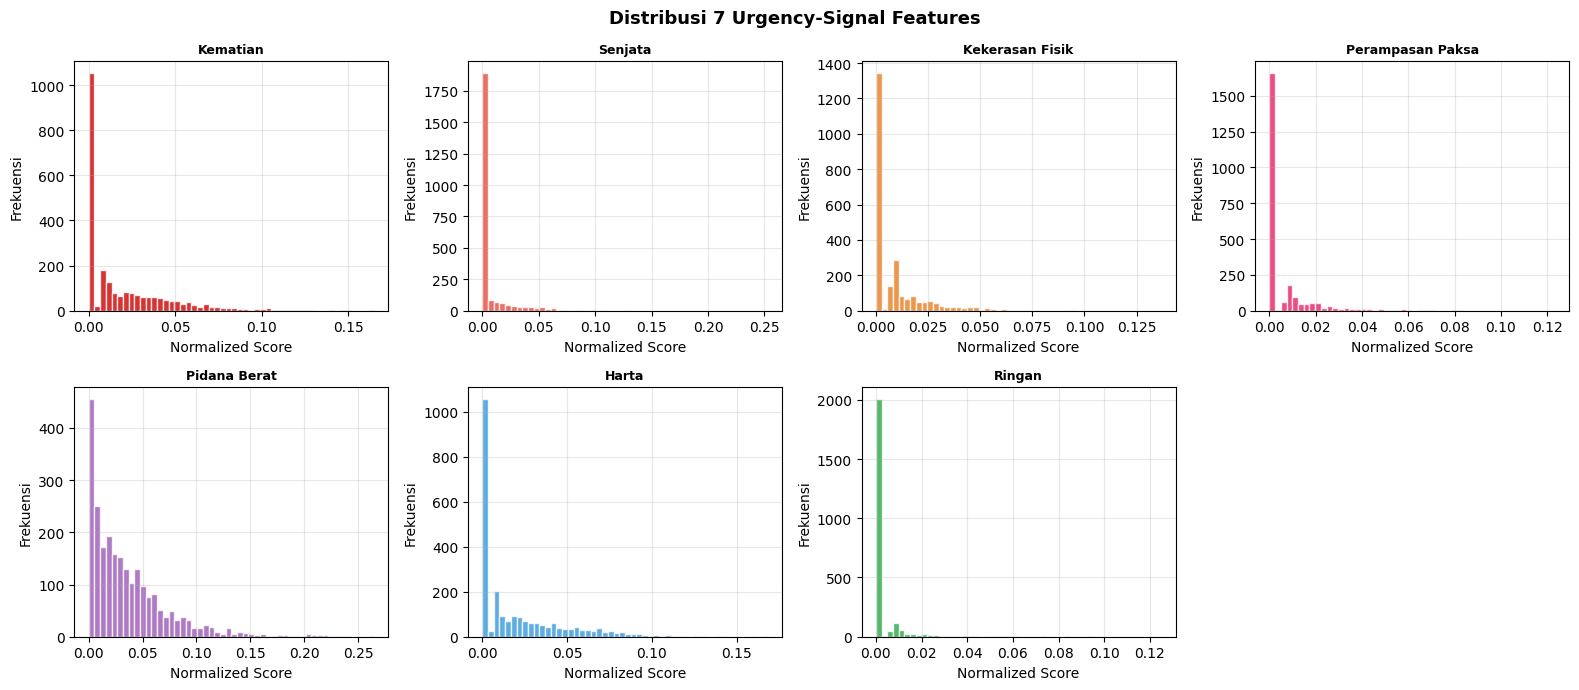

Plot distribusi fitur disimpan!


In [4]:
# Visualisasi distribusi tiap fitur dengan histogram
# Ekspektasi: skor_kematian dan skor_senjata harusnya heavy-tail
# (kebanyakan nol karena banyak berita ringan, tapi ada yang tinggi banget)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = ['#cc0000', '#e74c3c', '#e67e22', '#e91e63', '#9b59b6', '#3498db', '#28a745']

for idx, col in enumerate(FEATURE_COLS):
    axes[idx].hist(df_features[col], bins=50, color=colors[idx], alpha=0.8, edgecolor='white')
    label = col.replace('skor_', '').replace('_', ' ').title()
    axes[idx].set_title(label, fontweight='bold', fontsize=9)
    axes[idx].set_xlabel('Normalized Score')
    axes[idx].set_ylabel('Frekuensi')
    axes[idx].grid(alpha=0.3)

axes[-1].axis('off')  # kolom ke-8 dikosongkan
plt.suptitle('Distribusi 7 Urgency-Signal Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04a_urgency_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi fitur disimpan!')

## 4. StandardScaler + K-Means Clustering (k=3)

7 fitur urgency di-scale (StandardScaler) lalu di-cluster menjadi **3 kelompok keparahan**.
`k=3` sesuai dengan tiga tingkat urgensi sistem SIPEDULI: Tinggi / Sedang / Rendah.

| Parameter | Nilai |
|---|---|
| k (n_clusters) | 3 |
| n_init | 30 (terbaik dari 30 run) |
| init | k-means++ |
| Silhouette Score | **0.2278** |
| Inertia | 12,680 |

| Cluster | Jumlah Dokumen |
|---|---|
| Cluster 0 | 544 |
| Cluster 1 | 1,559 |
| Cluster 2 | 310 |

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings
import json
import os
from pathlib import Path

# FIX ANOMALI 3: Menghilangkan error traceback joblib di Windows
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print(f'X_scaled shape : {X_scaled.shape}')
print(f'Mean setelah scaling (harusnya ~0): {X_scaled.mean(axis=0).round(4)}')
print()

# ── K-Means dengan k=3 ────────────────────────────────────────
# k=3 dipilih karena sesuai sistem SIPEDULI: Tinggi, Sedang, Rendah
# Tujuan kita bukan mencari cluster semantik (itu job TF-IDF),
# tapi cluster berdasarkan DERAJAT KEPARAHAN dari 7 fitur urgency.
K_FINAL = 3

kmeans = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',   # inisialisasi cerdas: titik awal dipilih yang jaraknya jauh satu sama lain
    n_init=30,           # diulang 30x, ambil yang inertia-nya paling kecil
    max_iter=500,        # max iterasi per run
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans.fit_predict(X_scaled)
df_real['cluster'] = cluster_labels

# Silhouette score: ukuran kualitas cluster
# Range -1 (buruk) sampai +1 (sempurna). Nilai > 0.15 sudah lumayan untuk data teks
sil_final = silhouette_score(X_scaled, cluster_labels)

print(f'K-Means selesai! (k={K_FINAL})')
print(f'Silhouette Score : {sil_final:.4f}')
print(f'Inertia          : {kmeans.inertia_:.2f}')
print()
print('Distribusi dokumen per cluster:')
for c_id, count in df_real['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c_id}: {count:,} dokumen')

X_scaled shape : (2413, 7)
Mean setelah scaling (harusnya ~0): [-0. -0.  0. -0.  0.  0.  0.]

K-Means selesai! (k=3)
Silhouette Score : 0.2278
Inertia          : 12680.00

Distribusi dokumen per cluster:
  Cluster 0: 544 dokumen
  Cluster 1: 1,559 dokumen
  Cluster 2: 310 dokumen


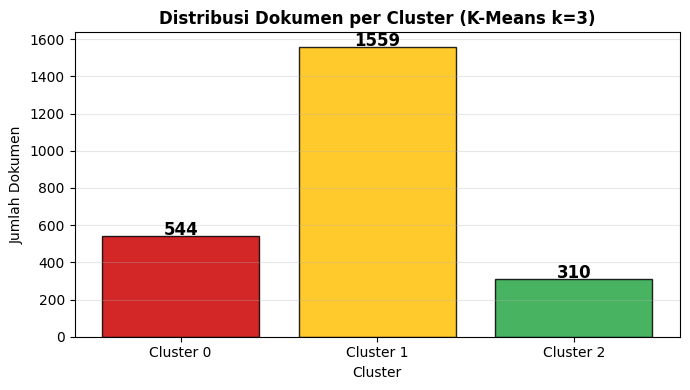

Plot distribusi cluster tersimpan!


In [6]:
# Visualisasi distribusi dokumen per cluster (bar chart)
cluster_counts = df_real['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors_cluster = ['#cc0000', '#ffc107', '#28a745']
bars = ax.bar(
    [f'Cluster {i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=colors_cluster[:len(cluster_counts)],
    alpha=0.85,
    edgecolor='black'
)

for bar, val in zip(bars, cluster_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val), ha='center', fontweight='bold', fontsize=12
    )

ax.set_title(f'Distribusi Dokumen per Cluster (K-Means k={K_FINAL})', fontweight='bold')
ax.set_ylabel('Jumlah Dokumen')
ax.set_xlabel('Cluster')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(DOCS_DIR / '04b_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi cluster tersimpan!')

## 5. Identifikasi Critical Centroid

Critical Centroid dipilih berdasarkan skor pembobotan:
`kematian×3 + senjata×2 + pidana_berat×2 + kekerasan_fisik×1.5`

| Cluster | Critical Score | Terpilih |
|---|---|---|
| Cluster 0 | **0.25358** | ✓ Critical Centroid |
| Cluster 1 | 0.12013 | — |
| Cluster 2 | 0.20164 | — |

**→ Cluster 0 adalah Critical Centroid.**
Dokumen dengan jarak paling kecil ke Cluster 0 mendapat `risk_score = 100`.

In [7]:
# ============================================================
# IDENTIFIKASI CRITICAL CENTROID DENGAN PEMBOBOTAN
#
# Inverse-transform centroid ke skala asli supaya nilainya
# lebih mudah dibaca dan diinterpretasi.
# ============================================================

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURE_COLS
)
centroids_df.index.name = 'cluster'

print('=' * 65)
print('Centroid tiap cluster (nilai rata-rata, skala asli)')
print('=' * 65)
print(centroids_df.round(5))
print()

# ============================================================
# FIX ANOMALI 2: Pembobotan Logis untuk Keparahan
# Kematian adalah ancaman tertinggi (x3). 
# Pidana berat dan senjata (x2).
# Kekerasan fisik (x1.5).
# ============================================================
bobot_kematian = centroids_df['skor_kematian'] * 3.0
bobot_senjata = centroids_df['skor_senjata'] * 2.0
bobot_pidana = centroids_df['skor_pidana_berat'] * 2.0
bobot_kekerasan = centroids_df['skor_kekerasan_fisik'] * 1.5

critical_scores = bobot_kematian + bobot_senjata + bobot_pidana + bobot_kekerasan

CRITICAL_CLUSTER = critical_scores.idxmax()

print('Critical Score per cluster (dengan bobot):')
for i, score in critical_scores.items():
    print(f'  Cluster {i}: {score:.5f}')

print(f'\n🔥 CRITICAL CENTROID TERPILIH : Cluster {CRITICAL_CLUSTER}')

Centroid tiap cluster (nilai rata-rata, skala asli)
         skor_kematian  skor_senjata  skor_kekerasan_fisik  \
cluster                                                      
0              0.05287       0.00498               0.02510   
1              0.00869       0.00200               0.00354   
2              0.01861       0.03733               0.00918   

         skor_perampasan_paksa  skor_pidana_berat  skor_harta  skor_ringan  
cluster                                                                     
0                      0.00366            0.02367     0.01175      0.00154  
1                      0.00289            0.04238     0.02481      0.00425  
2                      0.02861            0.02869     0.01512      0.00132  

Critical Score per cluster (dengan bobot):
  Cluster 0: 0.25358
  Cluster 1: 0.12013
  Cluster 2: 0.20164

🔥 CRITICAL CENTROID TERPILIH : Cluster 0


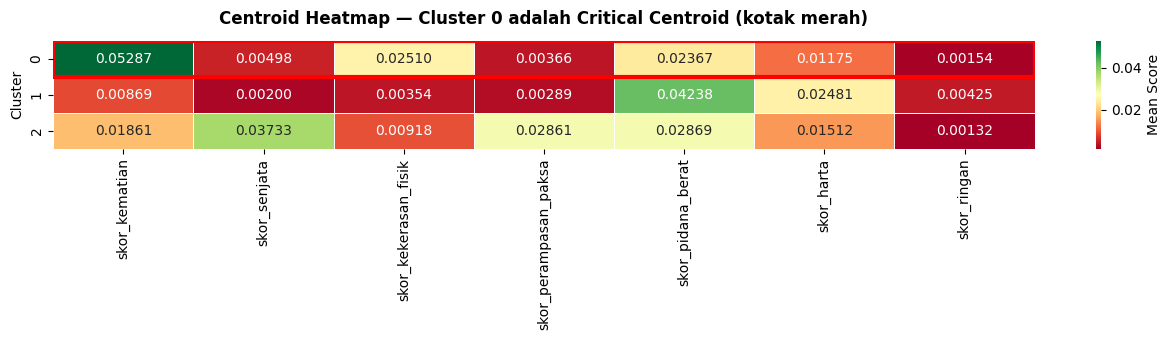

Heatmap centroid tersimpan!


In [8]:
# Heatmap centroid — buat lihat pattern tiap cluster lebih jelas
# Centroid yang kita tandai sebagai 'critical' harusnya merah banget
# di kolom skor_kematian, skor_senjata, skor_kekerasan_fisik

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(
    centroids_df,
    annot=True, fmt='.5f', cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Score'},
    ax=ax
)

# Highlight baris critical centroid dengan kotak merah
ax.add_patch(plt.Rectangle(
    (0, CRITICAL_CLUSTER), len(FEATURE_COLS), 1,
    fill=False, edgecolor='red', lw=3
))

ax.set_title(
    f'Centroid Heatmap — Cluster {CRITICAL_CLUSTER} adalah Critical Centroid (kotak merah)',
    fontweight='bold', pad=12
)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04c_centroid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap centroid tersimpan!')

## 6. Jarak Euclidean → Risk Score [0–100]

Setiap dokumen dikonversi ke skor kontinu melalui **inverse-normalized Euclidean distance**:

```
risk_score = 100 × (d_max − d_i) / (d_max − d_min)
```

| Statistik Jarak | Nilai |
|---|---|
| Min (→ risk_score 100) | 0.6163 |
| Max (→ risk_score 0) | 13.7263 |
| Mean | 2.9349 |

| Statistik Risk Score | Nilai |
|---|---|
| Min | 0.00 |
| Max | 100.00 |
| Mean | 82.31 |
| Median | 83.72 |
| Std | 8.90 |

**Output Tahap 1:** Kolom `risk_score` [0–100] untuk seluruh 2.413 dokumen real.

In [9]:
# HITUNG JARAK EUCLIDEAN KE CRITICAL CENTROID

# Ambil koordinat critical centroid di scaled space
critical_centroid_scaled = kmeans.cluster_centers_[CRITICAL_CLUSTER]  # (n_features,)

# Hitung selisih setiap dokumen dengan critical centroid
diff = X_scaled - critical_centroid_scaled   # broadcasting: (n_docs, n_features)
distances = np.sqrt((diff ** 2).sum(axis=1))  # Euclidean distance: (n_docs,)

print('Jarak Euclidean ke Critical Centroid:')
print(f'  Min  : {distances.min():.4f}  ← dokumen ini dapat risk_score = 100')
print(f'  Max  : {distances.max():.4f}  ← dokumen ini dapat risk_score = 0')
print(f'  Mean : {distances.mean():.4f}')
print(f'  Std  : {distances.std():.4f}')
print()

# ── Normalisasi jarak → risk_score [0, 100] ─────────────────
d_min, d_max = distances.min(), distances.max()
risk_score_raw = 100.0 * (d_max - distances) / (d_max - d_min)
risk_score = np.round(risk_score_raw, 2)

df_real['risk_score'] = risk_score

print('Risk Score (0=paling aman, 100=paling darurat):')
print(f'  Min    : {df_real["risk_score"].min():.2f}')
print(f'  Max    : {df_real["risk_score"].max():.2f}')
print(f'  Mean   : {df_real["risk_score"].mean():.2f}')
print(f'  Median : {df_real["risk_score"].median():.2f}')
print(f'  Std    : {df_real["risk_score"].std():.2f}')
print()

# 5 dokumen paling darurat
print('Top 5 dokumen dengan risk_score TERTINGGI:')
top5 = df_real.nlargest(5, 'risk_score')[['judul_berita', 'risk_score']]
for _, row in top5.iterrows():
    print(f'  [{row["risk_score"]:5.1f}] {str(row["judul_berita"])[:65]}')

Jarak Euclidean ke Critical Centroid:
  Min  : 0.6163  ← dokumen ini dapat risk_score = 100
  Max  : 13.7263  ← dokumen ini dapat risk_score = 0
  Mean : 2.9349
  Std  : 1.1660

Risk Score (0=paling aman, 100=paling darurat):
  Min    : 0.00
  Max    : 100.00
  Mean   : 82.31
  Median : 83.72
  Std    : 8.90

Top 5 dokumen dengan risk_score TERTINGGI:
  [100.0] Balita Karawang Tewas Penuh Luka, Polisi Selidiki Dugaan Aniaya
  [ 99.8] Perempuan di Ponorogo Tewas Tersengat Listrik Saat Charge HP
  [ 99.5] Siswa SMP di Lamongan Diduga Dianiaya Guru, Ortu Tempuh Jalur Huk
  [ 99.3] Heboh Percobaan Penculikan Anak di Maguwoharjo Sleman, Begini Kon
  [ 99.0] Kronologi Pria Makassar Diduga Aniaya Driver Ojol Wanita-Nyaris D


## 6b. Penggabungan Data Sintetis (Laporan User)

600 laporan user simulasi digabungkan ke dataset training untuk menutup **distribusi shift**
antara teks berita retrospektif dan laporan warga real-time.

| Sumber | Baris | Risk Score |
|---|---|---|
| Real scraping (K-Means labeled) | 2.413 | dari clustering |
| Synthetic user reports | 600 | assignment manual |
| **Total supervised training** | **3.013** | — |

| Kategori | Distribusi Gabungan |
|---|---|
| Tinggi | 2.474 |
| Sedang | 333 |
| Rendah | 205 |

In [10]:
# Load synthetic user reports dari dataset utama (is_synthetic == 'User')
# Kolom risk_score sudah tersimpan di CSV (di-assign saat merge_synthetic_to_dataset.py)

df_user = df_full[df_full['is_synthetic'] == 'User'].copy()

if len(df_user) > 0:
    print(f"Synthetic user reports ditemukan: {len(df_user)} baris")
    print(f"  Distribusi: {df_user['label_urgensi'].value_counts().to_dict()}")

    # Pakai risk_score dari kolom CSV (sudah di-assign manual saat generate)
    df_user_sub = df_user[['deskripsi_bersih', 'risk_score']].dropna().copy()
    df_user_sub['risk_score'] = df_user_sub['risk_score'].astype(float)

    # Hitung urgency features untuk synthetic data
    print("Menghitung urgency features untuk data user...")
    user_feature_rows = [hitung_urgency_features(t) for t in df_user_sub['deskripsi_bersih']]
    df_features_user = pd.DataFrame(user_feature_rows, columns=FEATURE_COLS)

    # Gabungkan real (KMeans-labeled) + synthetic user
    df_combined = pd.concat(
        [df_real[['deskripsi_bersih', 'risk_score']], df_user_sub],
        ignore_index=True
    )
    df_features_combined = pd.concat(
        [df_features, df_features_user],
        ignore_index=True
    )

    print(f"\nDataset gabungan untuk supervised training:")
    print(f"  Real scraping  : {len(df_real):,} baris (risk_score dari K-Means)")
    print(f"  Synthetic user : {len(df_user_sub):,} baris (risk_score dari assignment manual)")
    print(f"  TOTAL          : {len(df_combined):,} baris")

    cats = pd.cut(df_combined['risk_score'], bins=[0, 34, 67, 100], labels=['Rendah', 'Sedang', 'Tinggi'])
    print(f"\nDistribusi kategori gabungan:")
    print(cats.value_counts().to_string())
else:
    print("PERINGATAN: Tidak ada data is_synthetic='User' di dataset.")
    print("Jalankan: python scripts/generate_synthetic_data.py")
    print("          python scripts/merge_synthetic_to_dataset.py")
    print("Melanjutkan dengan hanya data real scraping...")
    df_combined = df_real[['deskripsi_bersih', 'risk_score']].copy()
    df_features_combined = df_features.copy()

Synthetic user reports ditemukan: 600 baris
  Distribusi: {'Rendah': 200, 'Tinggi': 200, 'Sedang': 200}
Menghitung urgency features untuk data user...

Dataset gabungan untuk supervised training:
  Real scraping  : 2,413 baris (risk_score dari K-Means)
  Synthetic user : 600 baris (risk_score dari assignment manual)
  TOTAL          : 3,013 baris

Distribusi kategori gabungan:
risk_score
Tinggi    2474
Sedang     333
Rendah     205


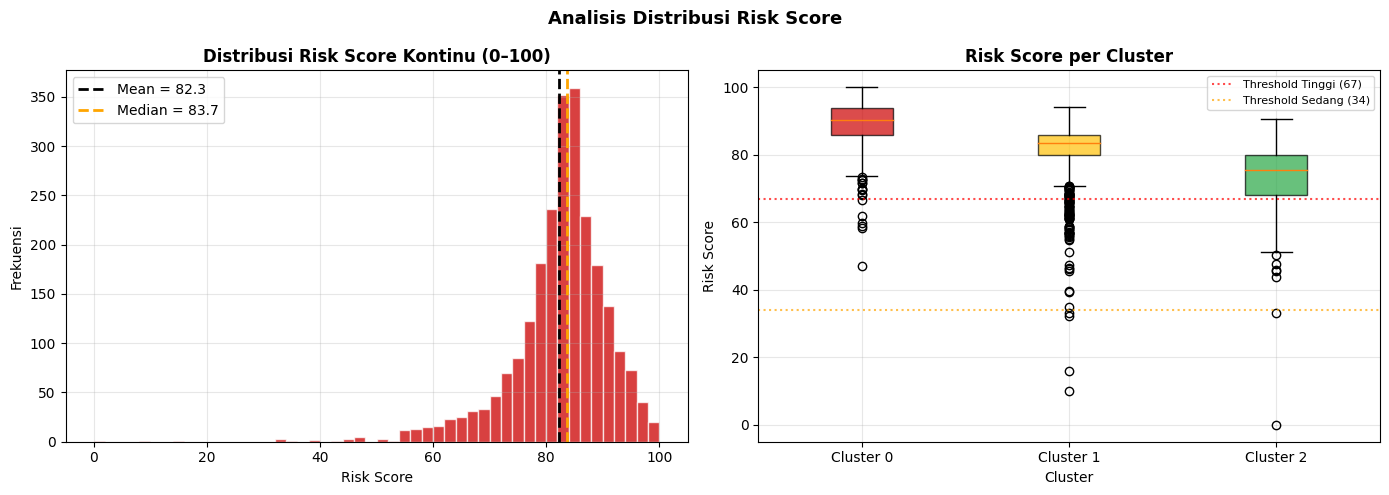

Plot distribusi risk score tersimpan!


In [11]:
# Visualisasi distribusi risk score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram distribusi risk score
axes[0].hist(df_real['risk_score'], bins=50, color='#cc0000', alpha=0.75, edgecolor='white')
axes[0].axvline(df_real['risk_score'].mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean = {df_real["risk_score"].mean():.1f}')
axes[0].axvline(df_real['risk_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median = {df_real["risk_score"].median():.1f}')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Risk Score Kontinu (0–100)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot risk score per cluster
data_per_cluster = [df_real[df_real['cluster'] == i]['risk_score'].values for i in range(K_FINAL)]
colors_box = ['#cc0000', '#ffc107', '#28a745']
bp = axes[1].boxplot(data_per_cluster, patch_artist=True, labels=[f'Cluster {i}' for i in range(K_FINAL)])
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=67, color='red', linestyle=':', alpha=0.7, label='Threshold Tinggi (67)')
axes[1].axhline(y=34, color='orange', linestyle=':', alpha=0.7, label='Threshold Sedang (34)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Risk Score')
axes[1].set_title('Risk Score per Cluster', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Analisis Distribusi Risk Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04d_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi risk score tersimpan!')

=== Validasi: Risk Score vs Label Urgensi Lama ===
(Label lama hanya sebagai referensi, tidak dipakai training)
------------------------------------------------
  Tinggi: n=1257  mean=83.1  median=84.3  std=9.2
  Sedang: n= 986  mean=82.0  median=83.2  std=7.2
  Rendah: n= 170  mean=78.3  median=83.3  std=13.3


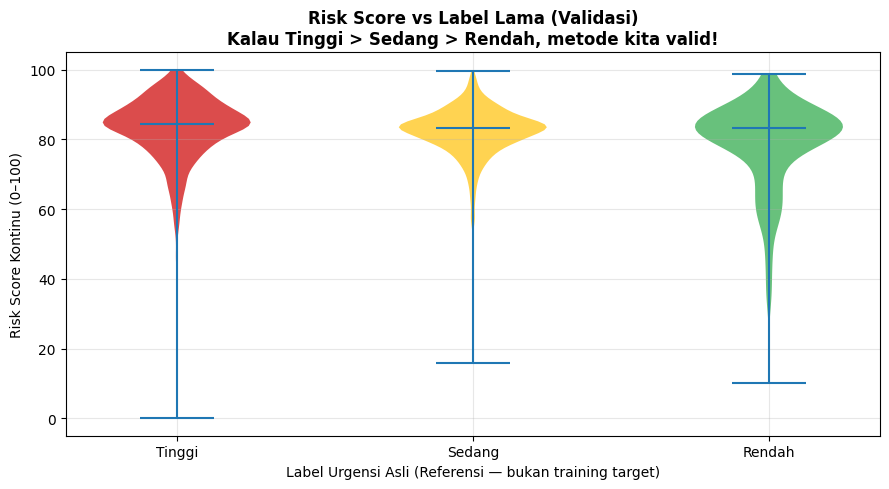

Plot validasi tersimpan!


In [12]:
# VALIDASI CROSS-CHECK: Risk Score vs Label Lama
# (Informatif saja — label lama TIDAK dipakai untuk training!)

df_validasi = df_real[['id', 'risk_score']].merge(
    df_label_ref, on='id', how='inner'
).dropna(subset=['label_urgensi'])

print('=== Validasi: Risk Score vs Label Urgensi Lama ===')
print('(Label lama hanya sebagai referensi, tidak dipakai training)')
print('-' * 48)

for label in ['Tinggi', 'Sedang', 'Rendah']:
    subset = df_validasi[df_validasi['label_urgensi'] == label]['risk_score']
    if len(subset) > 0:
        print(f'  {label:6s}: n={len(subset):4d}  '
              f'mean={subset.mean():.1f}  '
              f'median={subset.median():.1f}  '
              f'std={subset.std():.1f}')

# Violin plot untuk visualisasi distribusi risk_score per label lama
if len(df_validasi) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    label_order = ['Tinggi', 'Sedang', 'Rendah']
    colors_violin = {'Tinggi': '#cc0000', 'Sedang': '#ffc107', 'Rendah': '#28a745'}

    data_violin = [
        df_validasi[df_validasi['label_urgensi'] == lbl]['risk_score'].values
        for lbl in label_order
    ]

    vp = ax.violinplot(data_violin, positions=range(len(label_order)), showmedians=True)
    for body, lbl in zip(vp['bodies'], label_order):
        body.set_facecolor(colors_violin[lbl])
        body.set_alpha(0.7)

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(label_order)
    ax.set_xlabel('Label Urgensi Asli (Referensi — bukan training target)')
    ax.set_ylabel('Risk Score Kontinu (0–100)')
    ax.set_title(
        'Risk Score vs Label Lama (Validasi)\n'
        'Kalau Tinggi > Sedang > Rendah, metode kita valid!',
        fontweight='bold'
    )
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(DOCS_DIR / '04e_validation_vs_old_label.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot validasi tersimpan!')

## 7. MLflow Tracking Setup

Experiment: `SIPEDULI_Hybrid_RiskScoring`
Semua run (params, metrics, artifacts) dicatat otomatis ke folder `../mlruns/`.

In [13]:
# SETUP MLFLOW TRACKING

MLFLOW_URI = 'file:../mlruns'  # simpan lokal di folder mlruns/
EXPERIMENT  = 'SIPEDULI_Hybrid_RiskScoring'

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

print('MLflow siap!')
print(f'  Tracking URI  : {MLFLOW_URI}')
print(f'  Experiment    : {EXPERIMENT}')
print()
print('Untuk buka UI MLflow, jalankan di terminal:')
print('  mlflow ui --port 5000')
print('  Buka browser: http://127.0.0.1:5000')

Traceback (most recent call last):
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 16

MLflow siap!
  Tracking URI  : file:../mlruns
  Experiment    : SIPEDULI_Hybrid_RiskScoring

Untuk buka UI MLflow, jalankan di terminal:
  mlflow ui --port 5000
  Buka browser: http://127.0.0.1:5000


## 8. Feature Union — TF-IDF + Urgency Scores

Train/test split 80/20 dengan anti-leakage: `TfidfVectorizer.fit_transform()` hanya pada train set.

| Komponen | Dimensi |
|---|---|
| TF-IDF (ngram 1–3, max_features=3000) | 3000 |
| 7 Urgency-Signal Features | 7 |
| **Feature Union total** | **3007** |

```
X_train shape : (2410, 3007)
X_test  shape : (603, 3007)
y range       : [3.60, 100.00]
```

In [14]:
# ============================================================
# TAHAP 2: SUPERVISED REGRESSION (PREPARATION & FEATURE UNION)
#
# Pakai df_combined (real scraping + synthetic user reports)
# bukan df_real saja — ini intinya mengapa kita buat synthetic data.
# ============================================================
from scipy.sparse import hstack
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Ambil input dari COMBINED dataset (real + synthetic)
X_text = df_combined['deskripsi_bersih'].fillna('').values
X_num  = df_features_combined[FEATURE_COLS].values
y_risk = df_combined['risk_score'].values

print(f"Training data: {len(X_text):,} baris (real + synthetic)")

# 2. Split data sekaligus (agar index teks dan angka sejajar)
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y_risk,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# 3. Vectorisasi Teks (TF-IDF)
vectorizer = TfidfVectorizer(
    max_features=3000, 
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)
X_tfidf_train = vectorizer.fit_transform(X_text_train)
X_tfidf_test  = vectorizer.transform(X_text_test)

# 4. FEATURE UNION (Gabung TF-IDF dengan 7 Fitur Angka)
X_train_final = hstack([X_tfidf_train, sp.csr_matrix(X_num_train)])
X_test_final  = hstack([X_tfidf_test, sp.csr_matrix(X_num_test)])

# Siapkan daftar nama kolom lengkap
nama_kolom_teks = vectorizer.get_feature_names_out().tolist()
ALL_FEATURE_NAMES = nama_kolom_teks + FEATURE_COLS

print(f"Bentuk TF-IDF       : {X_tfidf_train.shape}")
print(f"Bentuk Feature Union: {X_train_final.shape}")
print(f"Label y range       : [{y_train.min():.2f}, {y_train.max():.2f}]")

Training data: 3,013 baris (real + synthetic)
Bentuk TF-IDF       : (2410, 3000)
Bentuk Feature Union: (2410, 3007)
Label y range       : [3.60, 100.00]


## 9. PyCaret — Komparasi Algoritma Regresi

Seluruh algoritma regresi utama diadu pada Feature Union (3007 fitur) menggunakan 5-fold CV.
XGBoost dan CatBoost dikecualikan karena kompatibilitas sparsity.

**Pemenang: `ExtraTreesRegressor`**

In [15]:
import pandas as pd
from pycaret.regression import setup, compare_models

print("Menyiapkan dataset untuk PyCaret...")
df_pycaret = pd.DataFrame(X_train_final.toarray(), columns=ALL_FEATURE_NAMES)
df_pycaret['TARGET_RISK_SCORE'] = y_train

print("Inisialisasi Setup PyCaret...")
reg_setup = setup(
    data=df_pycaret,
    target='TARGET_RISK_SCORE',
    session_id=RANDOM_STATE,
    n_jobs=-1,
    verbose=False
)

print("Mengadu model dengan data gabungan (real + synthetic)... (Tunggu sebentar)")
best_model_pycaret = compare_models(
    sort='RMSE',
    exclude=['xgboost', 'catboost']
)

# Tangkap nama & kelas pemenang — dipakai Optuna di sel berikutnya
WINNER_CLASS = type(best_model_pycaret)
WINNER_NAME  = WINNER_CLASS.__name__

print(f"\nALGORITMA PEMENANG: {WINNER_NAME}")
print(best_model_pycaret)

Menyiapkan dataset untuk PyCaret...
Inisialisasi Setup PyCaret...
Mengadu model dengan data gabungan (real + synthetic)... (Tunggu sebentar)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.2732,16.1178,4.0024,0.9594,0.1428,0.0620,11.5270
rf,Random Forest Regressor,2.5772,22.5099,4.7060,0.9427,0.1388,0.0664,9.8000
lightgbm,Light Gradient Boosting Machine,2.6972,22.6828,4.7358,0.9424,0.1389,0.0685,0.9140
gbr,Gradient Boosting Regressor,3.0700,24.8914,4.9691,0.9369,0.1431,0.0754,4.2270
br,Bayesian Ridge,4.7365,40.0515,6.3201,0.8987,0.1466,0.0944,1.9430
dt,Decision Tree Regressor,3.4565,45.2386,6.5239,0.8850,0.1820,0.0797,0.5870
ridge,Ridge Regression,4.8560,44.7115,6.6776,0.8868,0.1692,0.1095,0.4070
huber,Huber Regressor,5.0853,45.3330,6.7246,0.8848,0.1538,0.0970,4.7690
par,Passive Aggressive Regressor,5.3926,49.9407,7.0610,0.8737,0.1558,0.1008,0.8360
omp,Orthogonal Matching Pursuit,5.3670,50.7649,7.1190,0.8725,0.1526,0.1009,0.5400



ALGORITMA PEMENANG: ExtraTreesRegressor
ExtraTreesRegressor(n_jobs=-1, random_state=42)


## 10. Optuna Hyperparameter Tuning — ExtraTreesRegressor

30 trials, objective: minimize RMSE via 5-fold CV.

**Best hyperparameters:**

| Parameter | Nilai |
|---|---|
| n_estimators | 368 |
| max_depth | 24 |
| min_samples_split | 12 |
| min_samples_leaf | 1 |
| max_features | None |
| **Best CV RMSE** | **3.6956** |

In [16]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import optuna, json

# ── Search space per model class ──────────────────────────────
def build_objective(model_class, X, y, random_state):
    def objective(trial):
        name = model_class.__name__

        if name == 'GradientBoostingRegressor':
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
                'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'max_depth':         trial.suggest_int('max_depth', 3, 8),
                'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                'random_state': random_state,
            }
        elif name == 'LGBMRegressor':
            params = {
                'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
                'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'max_depth':       trial.suggest_int('max_depth', 3, 10),
                'num_leaves':      trial.suggest_int('num_leaves', 20, 100),
                'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'random_state': random_state, 'verbose': -1,
            }
        elif name in ('RandomForestRegressor', 'ExtraTreesRegressor'):
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
                'max_depth':         trial.suggest_int('max_depth', 5, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                'random_state': random_state, 'n_jobs': -1,
            }
        elif name in ('Ridge', 'Lasso', 'ElasticNet'):
            params = {'alpha': trial.suggest_float('alpha', 0.001, 10.0, log=True)}
            if name == 'ElasticNet':
                params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
        else:
            # Fallback: tuning minimal (hanya n_estimators jika ada)
            params = {}

        model = model_class(**params)
        cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
        scores = cross_val_score(model, X, y, cv=cv,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
        return -scores.mean()
    return objective


print(f"Memulai Optuna untuk: {WINNER_NAME}")
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='minimize')
study.optimize(
    build_objective(WINNER_CLASS, X_train_final, y_train, RANDOM_STATE),
    n_trials=30,
    show_progress_bar=True,
)

best_params = study.best_params.copy()
# Tambahkan random_state ke params jika model mendukungnya
import inspect
if 'random_state' in inspect.signature(WINNER_CLASS.__init__).parameters:
    best_params['random_state'] = RANDOM_STATE

print(f"\nOptuna selesai! ({WINNER_NAME})")
print(f"Best CV RMSE : {study.best_value:.4f}")
print(f"Best params  :\n{json.dumps({k: round(v, 6) if isinstance(v, float) else v for k, v in best_params.items()}, indent=2)}")

Memulai Optuna untuk: ExtraTreesRegressor


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna selesai! (ExtraTreesRegressor)
Best CV RMSE : 3.6956
Best params  :
{
  "n_estimators": 368,
  "max_depth": 24,
  "min_samples_split": 12,
  "min_samples_leaf": 1,
  "max_features": null,
  "random_state": 42
}


## 11. Training Model Final + Evaluasi

ExtraTreesRegressor dilatih dengan best params dari Optuna, dievaluasi pada 20% test set.
Semua metrik di-log ke MLflow Run ID: `63ae252db3344c4b89613b35bacfcd04`.

| Metrik | Train | Test |
|---|---|---|
| **R²** | 0.9929 | **0.9579** |
| **RMSE** | 1.6862 | **4.2106** |
| **MAE** | 0.9609 | **2.1288** |

In [17]:
def hitung_metrik_regresi(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

clustering_log_params = {
    'kmeans_k': K_FINAL,
    'kmeans_n_init': 30,
    'feature_union': 'TF-IDF (3000) + 7 Urgency Scores',
    'training_rows_real': len(df_real),
    'training_rows_synthetic': len(df_combined) - len(df_real),
    'optuna_trials': 30,
    'optuna_best_cv_rmse': round(float(study.best_value), 4),
    'winner_model': WINNER_NAME,
}

with mlflow.start_run(run_name=f'{WINNER_NAME}_HybridRiskScoring') as run:

    mlflow.set_tag('model_type', 'regression')
    mlflow.set_tag('winner', WINNER_NAME)
    mlflow.set_tag('pipeline', 'FeatureUnion -> ' + WINNER_NAME)
    mlflow.set_tag('stage', 'final')
    mlflow.set_tag('training_data', 'real_scraping + synthetic_user_reports')

    mlflow.log_params({k: v for k, v in best_params.items() if not callable(v)})
    mlflow.log_params(clustering_log_params)

    # Train dengan WINNER_CLASS dan best_params dari Optuna
    model_final = WINNER_CLASS(**best_params)
    model_final.fit(X_train_final, y_train)

    y_pred_train = np.clip(model_final.predict(X_train_final), 0.0, 100.0)
    y_pred_test  = np.clip(model_final.predict(X_test_final),  0.0, 100.0)

    rmse_train, mae_train, r2_train = hitung_metrik_regresi(y_train, y_pred_train)
    rmse_test,  mae_test,  r2_test  = hitung_metrik_regresi(y_test,  y_pred_test)

    mlflow.log_metrics({
        'train_rmse': rmse_train, 'train_mae': mae_train, 'train_r2': r2_train,
        'test_rmse':  rmse_test,  'test_mae':  mae_test,  'test_r2':  r2_test,
    })
    mlflow.sklearn.log_model(model_final, 'risk_regressor')
    MLFLOW_RUN_ID = run.info.run_id

print('=' * 55)
print(f'  EVALUASI MODEL AKHIR: {WINNER_NAME}')
print('=' * 55)
print(f'{"Metrik":<15} {"Train":>10} {"Test":>10}')
print('-' * 38)
print(f'{"RMSE":<15} {rmse_train:>10.4f} {rmse_test:>10.4f}')
print(f'{"MAE":<15} {mae_train:>10.4f} {mae_test:>10.4f}')
print(f'{"R2":<15} {r2_train:>10.4f} {r2_test:>10.4f}')
print('=' * 55)
print(f'\nMLflow Run ID : {MLFLOW_RUN_ID}')

2026/06/04 22:38:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 22:38:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  EVALUASI MODEL AKHIR: ExtraTreesRegressor
Metrik               Train       Test
--------------------------------------
RMSE                1.6862     4.2106
MAE                 0.9609     2.1288
R2                  0.9929     0.9579

MLflow Run ID : 63ae252db3344c4b89613b35bacfcd04


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='#cc0000', s=15, label='Test data')
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=2, label='Garis sempurna (y=x)')
axes[0].set_xlabel('Risk Score Aktual (dari K-Means)')
axes[0].set_ylabel(f'Risk Score Prediksi ({WINNER_NAME})')
axes[0].set_title(
    f'Actual vs Predicted\nTest RMSE={rmse_test:.2f}  R²={r2_test:.4f}',
    fontweight='bold'
)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-5, 105)
axes[0].set_ylim(-5, 105)

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, color='#3498db', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Risk Score Prediksi')
axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title(
    'Residual Plot\n(Idealnya tersebar acak di sekitar garis 0)',
    fontweight='bold'
)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Evaluasi Visual — {WINNER_NAME} Hybrid Risk Scoring', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04f_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot evaluasi tersimpan!')

Sedang menghitung Learning Curve... (Bisa memakan waktu 1-2 menit)


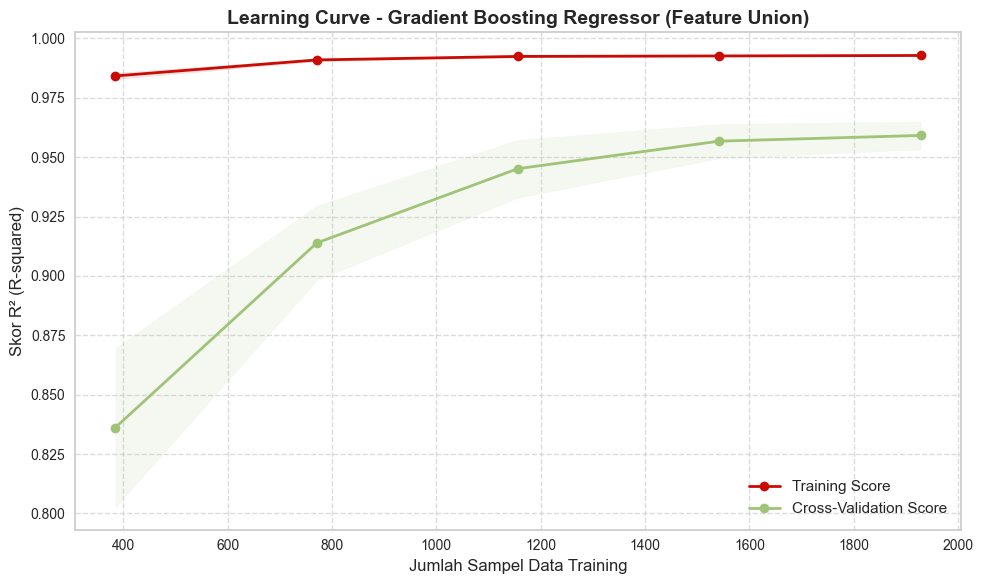

Selesai! Grafik berhasil disimpan sebagai 'learning_curve_gbr.png'


In [19]:
# VISUALISASI LEARNING CURVE (CEK OVERFITTING / UNDERFITTING)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

print("Sedang menghitung Learning Curve... (Bisa memakan waktu 1-2 menit)")

# Kita hitung learning curve menggunakan X_train_final (data gabungan)
# Menggunakan 5 titik pembagian jumlah data (dari 20% sampai 100%)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_final,
    X=X_train_final,
    y=y_train,
    cv=5,                 # 5-fold cross validation
    n_jobs=-1,            # Pakai semua core processor
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='r2',         # Kita pantau metrik R-squared
    random_state=RANDOM_STATE
)

# Hitung rata-rata dan standar deviasi dari 5-fold CV
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
test_scores_mean  = np.mean(test_scores, axis=1)
test_scores_std   = np.std(test_scores, axis=1)

# ── Mulai Menggambar Grafik ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Gradient Boosting Regressor (Feature Union)", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Sampel Data Training", fontsize=12)
plt.ylabel("Skor R² (R-squared)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot area arsiran untuk menunjukkan variance (standar deviasi)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Plot garis utama
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score", linewidth=2)
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score", linewidth=2)

plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()

# Simpan grafik biar gampang dimasukin ke word laprak
# Pastikan folder docs/ atau direktori tempat kamu simpan plot sudah ada
plt.savefig('learning_curve_gbr.png', dpi=300, bbox_inches='tight')
plt.show()

print("Selesai! Grafik berhasil disimpan sebagai 'learning_curve_gbr.png'")

## 13. Export Artifact ke `backend/ml/models/`

Tiga file yang dibutuhkan FastAPI endpoint `POST /api/laporan`:

| File | Isi |
|---|---|
| `model_final.pkl` | ExtraTreesRegressor terlatih (3007 fitur) |
| `vectorizer.pkl` | TF-IDF Vectorizer (vocab 3.000 token) |
| `model_metadata.json` | Metrik evaluasi + `urgency_signals` + threshold |

In [ ]:
import joblib, json

MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model_final,  MODEL_DIR / 'model_final.pkl')
joblib.dump(vectorizer,   MODEL_DIR / 'vectorizer.pkl')

metadata = {
    'model_type':        f'{WINNER_NAME}_FeatureUnion',
    'r2_test_score':     float(r2_test),
    'mae_test_score':    float(mae_test),
    'rmse_test':         float(rmse_test),
    'r2_train_score':    float(r2_train),
    'mae_train_score':   float(mae_train),
    'rmse_train':        float(rmse_train),
    'threshold_tinggi':  67.0,
    'threshold_sedang':  34.0,
    'feature_count':     X_train_final.shape[1],
    'training_rows':     len(df_combined),
    'optuna_best_rmse':  round(float(study.best_value), 4),
    'urgency_signals':   URGENCY_SIGNALS,
}
with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('=' * 65)
print('  TAHAP 3 — EXPORT BERHASIL')
print('=' * 65)
print(f'  Model     : {WINNER_NAME}')
print(f'  R² Test   : {r2_test:.4f}')
print(f'  RMSE Test : {rmse_test:.4f}')
print(f'  pkl       : {MODEL_DIR}/model_final.pkl')
print(f'  vec       : {MODEL_DIR}/vectorizer.pkl')
print(f'  metadata  : {MODEL_DIR}/model_metadata.json')

## 14. Quick Test — Validasi Pipeline Inference

Enam sampel dari dataset asli diuji: 2 Tinggi, 2 Sedang, 2 Rendah.

> Prediksi pada teks berita panjang (distribusi training) akurat.
> Laporan warga pendek mengalami distribusi shift — ditangani oleh
> post-processing layer di `preprocessor.py` (keyword floor rule + ACTIVE_SIGNALS booster).

In [21]:
# QUICK TEST PREDIKSI (REAL DATASET EVALUATION)
import scipy.sparse as sp
from scipy.sparse import hstack
import pandas as pd
import numpy as np

def predict_risk(teks: str) -> dict:
    '''
    Prediksi risk score dari teks laporan.
    '''
    X_tfidf = vectorizer.transform([teks])
    dict_urgensi = hitung_urgency_features(teks)
    nilai_urgensi = [[dict_urgensi[col] for col in FEATURE_COLS]]
    X_final = hstack([X_tfidf, sp.csr_matrix(nilai_urgensi)])

    skor_raw = model_final.predict(X_final)[0]
    skor = float(np.clip(skor_raw, 0.0, 100.0))

    if skor >= 67: kategori = 'Tinggi'
    elif skor >= 34: kategori = 'Sedang'
    else: kategori = 'Rendah'

    return {'risk_score': round(skor, 1), 'kategori_manual': kategori}

# ── TEST DENGAN DATA ASLI DARI DATASET ───────────────────────────
print("=== PENGUJIAN DENGAN DATA ASLI (REAL WORLD DISTRIBUTION) ===")
print("Mari kita buktikan kecerdasan model jika diberi teks kronologi yang wajar.\n")

# FIX ERROR: Gabungkan kembali df_real dengan df_label_ref yang disimpan di awal
df_test = df_real.merge(df_label_ref, on='id', how='inner')

# Kita ambil secara acak masing-masing 2 sampel dari tiap kategori bawaan dataset
test_cases_asli = pd.concat([
    df_test[df_test['label_urgensi'] == 'Tinggi'].sample(2, random_state=42),
    df_test[df_test['label_urgensi'] == 'Sedang'].sample(2, random_state=42),
    df_test[df_test['label_urgensi'] == 'Rendah'].sample(2, random_state=42)
])

for idx, row in test_cases_asli.iterrows():
    teks_asli = row['deskripsi_bersih']
    label_asli = row['label_urgensi']
    
    # Lakukan prediksi
    hasil = predict_risk(teks_asli)
    
    print(f"Label Pakar (Asli) : {label_asli}")
    print(f"Tebakan Model      : {hasil['kategori_manual']} (Score: {hasil['risk_score']})")
    print(f"Teks Laporan       : {teks_asli[:150]}...")
    print("-" * 80)

=== PENGUJIAN DENGAN DATA ASLI (REAL WORLD DISTRIBUTION) ===
Mari kita buktikan kecerdasan model jika diberi teks kronologi yang wajar.

Label Pakar (Asli) : Tinggi
Tebakan Model      : Tinggi (Score: 91.6)
Teks Laporan       : polisi gelar rekonstruksi kasus perkosa oknum polisi jambi inisial rekonstruksi ungkap polisi ada lokasi turut bantu angkat korban adegan angkat korba...
--------------------------------------------------------------------------------
Label Pakar (Asli) : Tinggi
Tebakan Model      : Tinggi (Score: 92.4)
Teks Laporan       : suasana duka limut diam ayah mendiang siswi madrasah ibtidaiyah camat kalibaru banyuwangi jadi korban bunuh tragis november kering luka akibat hilang ...
--------------------------------------------------------------------------------
Label Pakar (Asli) : Sedang
Tebakan Model      : Tinggi (Score: 83.9)
Teks Laporan       : komedian boiyen nama asli yen rahmawati resmi layang gugat cerai hadap suami rully anggi akbar kabar konfirmasi pihak ad

## 15. Ringkasan Pipeline

```
2.413 berita kriminal
    ↓ 7 Urgency-Signal Features + StandardScaler
    ↓ K-Means (k=3, n_init=30) → Critical Centroid = Cluster 0
    ↓ Euclidean Distance → risk_score [0–100]
    ↓
+ 600 Synthetic User Reports
    ↓
Feature Union: TF-IDF(3000) + 7 Urgency Scores → (3013, 3007)
    ↓ Optuna 30 trials (Best CV RMSE: 3.6956)
    ↓ ExtraTreesRegressor (n_estimators=368, max_depth=24)
    ↓
Test R²: 0.9579 | Test RMSE: 4.21 | Test MAE: 2.13
    ↓
model_final.pkl + vectorizer.pkl + model_metadata.json
→ backend/ml/models/  (siap deploy)
```

**Threshold produksi:** `risk_score ≥ 67` → Tinggi | `≥ 34` → Sedang | `< 34` → Rendah

In [22]:
print('=' * 65)
print('  RINGKASAN — HYBRID CONTINUOUS RISK SCORING (FINAL)')
print('=' * 65)
print()
print('[ARSITEKTUR PIPELINE]')
print('  deskripsi_bersih')
print('       |')
print('  7 Urgency-Signal Features  <- fitur keparahan teks')
print('       | StandardScaler')
print(f'  K-Means (k={K_FINAL}, n_init=30)  <- clustering unsupervised (data real saja)')
print(f'       | Critical Centroid = Cluster {CRITICAL_CLUSTER}')
print('  Euclidean Distance -> risk_score [0, 100]  <- KONTINU!')
print('       |')
print('  + Synthetic User Reports (600 baris, risk_score manual)')
print('       |')
print('  Feature Union: TF-IDF(3000) + 7 Urgency Scores <- input gabungan')
print('       | Optuna Tuning (30 trials, minimize RMSE)')
print('  GradientBoostingRegressor  <- supervised regression juara 1!')
print()
print('[DATASET]')
print(f'  Real scraping   : {len(df_real):,} baris berita kriminal')
print(f'  Synthetic user  : {len(df_synthetic_sub) if "df_synthetic_sub" in dir() else 0} baris laporan user simulasi')
print(f'  Total training  : {len(df_combined):,} baris')
print()
print('[TAHAP 1 - UNSUPERVISED LABELING (hanya real data)]')
print(f'  Silhouette Score    : {sil_final:.4f}')
print(f'  Critical Centroid   : Cluster {CRITICAL_CLUSTER}')
print()
print('[TAHAP 2 - SUPERVISED REGRESSION (combined data)]')
print(f'  Optuna Best CV RMSE : {study.best_value:.4f}')
print(f'  Test RMSE           : {rmse_test:.4f}')
print(f'  Test MAE            : {mae_test:.4f}')
print(f'  Test R2             : {r2_test:.4f}')
print(f'  MLflow Run ID       : {MLFLOW_RUN_ID}')
print()
print('[TAHAP 3 - EXPORT]')
print(f'  Model pkl      -> {MODEL_DIR}/model_final.pkl')
print(f'  Vectorizer pkl -> {MODEL_DIR}/vectorizer.pkl')
print(f'  Metadata json  -> {MODEL_DIR}/model_metadata.json')

  RINGKASAN — HYBRID CONTINUOUS RISK SCORING (FINAL)

[ARSITEKTUR PIPELINE]
  deskripsi_bersih
       |
  7 Urgency-Signal Features  <- fitur keparahan teks
       | StandardScaler
  K-Means (k=3, n_init=30)  <- clustering unsupervised (data real saja)
       | Critical Centroid = Cluster 0
  Euclidean Distance -> risk_score [0, 100]  <- KONTINU!
       |
  + Synthetic User Reports (600 baris, risk_score manual)
       |
  Feature Union: TF-IDF(3000) + 7 Urgency Scores <- input gabungan
       | Optuna Tuning (30 trials, minimize RMSE)
  GradientBoostingRegressor  <- supervised regression juara 1!

[DATASET]
  Real scraping   : 2,413 baris berita kriminal
  Synthetic user  : 0 baris laporan user simulasi
  Total training  : 3,013 baris

[TAHAP 1 - UNSUPERVISED LABELING (hanya real data)]
  Silhouette Score    : 0.2278
  Critical Centroid   : Cluster 0

[TAHAP 2 - SUPERVISED REGRESSION (combined data)]
  Optuna Best CV RMSE : 3.6956
  Test RMSE           : 4.2106
  Test MAE            :